Logic:
Phase 1 -> Forward Pass only using Numpy
Phase 2 -> Manual Backprop
Phase 3 -> Train and Plot

In [1]:
import numpy as np
import matplotlib.pyplot as plt


Activation Functions

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1 - s)

def softplus(x):
    return np.log1p(np.exp(x))

def softplus_deriv(x):
    return sigmoid(x)


Initialise Weights

In [9]:
class ISNN_Numpy:
    def __init__(self, hidden_dim=10):
        self.hidden_dim = hidden_dim

        # y branch
        self.Wy = np.random.randn(1, hidden_dim) * 0.1
        self.by = np.zeros((1, hidden_dim))

        # z branch
        self.Wz = np.random.randn(1, hidden_dim) * 0.1
        self.bz = np.zeros((1, hidden_dim))

        # t branch
        self.Wt = np.random.randn(1, hidden_dim) * 0.1
        self.bt = np.zeros((1, hidden_dim))

        # x branch
        self.Wx = np.random.randn(1 + 3 * hidden_dim, hidden_dim) * 0.1
        self.bx = np.zeros((1, hidden_dim))

        self.Wout = np.random.randn(hidden_dim, 1) * 0.1
        self.bout = np.zeros((1, 1))

#Forward Pass
    def forward(self, X):
        # Split inputs
        self.x = X[:, 0:1]
        self.y = X[:, 1:2]
        self.t = X[:, 2:3]
        self.z = X[:, 3:4]

        # ---- y branch ----
        self.y_lin = self.y @ self.Wy + self.by
        self.y_act = softplus(self.y_lin)

        # ---- z branch ----
        self.z_lin = self.z @ self.Wz + self.bz
        self.z_act = sigmoid(self.z_lin)

        # ---- t branch ----
        self.t_lin = self.t @ self.Wt + self.bt
        self.t_act = sigmoid(self.t_lin)

        # ---- combine ----
        self.combined = np.concatenate(
            [self.x, self.y_act, self.z_act, self.t_act], axis=1
        )

        # ---- x branch ----
        self.x_lin = self.combined @ self.Wx + self.bx
        self.x_act = softplus(self.x_lin)

        # ---- output ----
        self.out = self.x_act @ self.Wout + self.bout

        return self.out

#-------------------
#Backward Pass
#-------------------
    def backward(self, y_true, lr=0.001):
        N = y_true.shape[0]

        # ---- loss gradient ----
        d_out = 2 * (self.out - y_true.reshape(-1, 1)) / N

        # d(out)/dWout
        dWout = self.x_act.T @ d_out
        dbout = np.sum(d_out, axis=0, keepdims=True)

        # backprop into x_act
        dx_act = d_out @ self.Wout.T

#X branch
        dx_lin = dx_act * softplus_deriv(self.x_lin)

        dWx = self.combined.T @ dx_lin
        dbx = np.sum(dx_lin, axis=0, keepdims=True)

        d_combined = dx_lin @ self.Wx.T

#Split Gradients
        # split back into parts
        dx = d_combined[:, 0:1]
        dy = d_combined[:, 1:1+self.hidden_dim]
        dz = d_combined[:, 1+self.hidden_dim:1+2*self.hidden_dim]
        dt = d_combined[:, 1+2*self.hidden_dim:]

#Y Branch
        dy_lin = dy * softplus_deriv(self.y_lin)

        dWy = self.y.T @ dy_lin
        dby = np.sum(dy_lin, axis=0, keepdims=True)

#Branch Z
        dz_lin = dz * sigmoid_deriv(self.z_lin)

        dWz = self.z.T @ dz_lin
        dbz = np.sum(dz_lin, axis=0, keepdims=True)

#Branch T
        dt_lin = dt * sigmoid_deriv(self.t_lin)

        dWt = self.t.T @ dt_lin
        dbt = np.sum(dt_lin, axis=0, keepdims=True)

#Update weights
        self.Wout -= lr * dWout
        self.bout -= lr * dbout

        self.Wx -= lr * dWx
        self.bx -= lr * dbx

        self.Wy -= lr * dWy
        self.by -= lr * dby

        self.Wz -= lr * dWz
        self.bz -= lr * dbz

        self.Wt -= lr * dWt
        self.bt -= lr * dbt


Test Forward Pass

In [10]:
model = ISNN_Numpy()

X = np.random.randn(5, 4)
out = model.forward(X)

print(out.shape)  # will be (5,1)

(5, 1)


Train Loop

In [11]:
def train_numpy(model, X, y, epochs=1000, lr=0.001):
    losses = []

    for epoch in range(epochs):
        preds = model.forward(X)
        loss = np.mean((preds.reshape(-1) - y.reshape(-1))**2)

        model.backward(y, lr)

        losses.append(loss)

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")

    return losses


Run Model and Graph for Train Loss

Epoch 0, Loss: 7.5496
Epoch 100, Loss: 0.7041
Epoch 200, Loss: 0.6371
Epoch 300, Loss: 0.6071
Epoch 400, Loss: 0.5802
Epoch 500, Loss: 0.5557
Epoch 600, Loss: 0.5334
Epoch 700, Loss: 0.5130
Epoch 800, Loss: 0.4944
Epoch 900, Loss: 0.4775


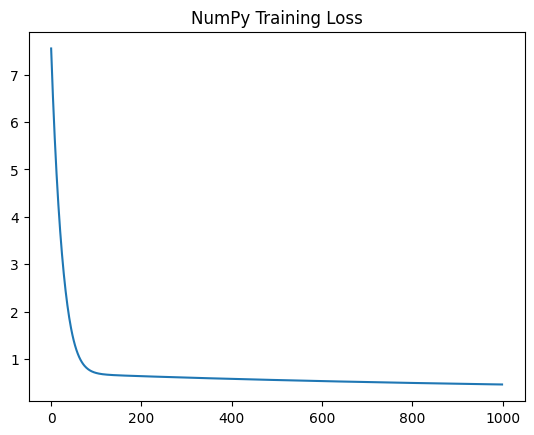

In [14]:
X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")

model_np = ISNN_Numpy()

losses = train_numpy(model_np, X_train, y_train, epochs=1000, lr=0.001)

#Plot check
plt.plot(losses)
plt.title("NumPy Training Loss")
plt.show()


Graph for Test Loss

In [15]:
def evaluate_numpy(model, X, y):
    preds = model.forward(X)
    loss = np.mean((preds.squeeze() - y)**2)
    return loss

Update Train loop

In [16]:
def train_numpy(model, X_train, y_train, X_test, y_test, epochs=1000, lr=0.001):
    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        preds = model.forward(X_train)
        loss = np.mean((preds.squeeze() - y_train)**2)

        model.backward(y_train, lr)

        # test loss
        test_loss = evaluate_numpy(model, X_test, y_test)

        train_losses.append(loss)
        test_losses.append(test_loss)

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Train: {loss:.4f}, Test: {test_loss:.4f}")

    return train_losses, test_losses

Run

In [17]:
X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")

X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

model_np = ISNN_Numpy()

train_losses_np, test_losses_np = train_numpy(
    model_np,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=1000,
    lr=0.001
)

Epoch 0, Train: 6.0739, Test: 5.7825
Epoch 100, Train: 0.7450, Test: 0.9992
Epoch 200, Train: 0.5264, Test: 0.9194
Epoch 300, Train: 0.5121, Test: 0.9082
Epoch 400, Train: 0.5008, Test: 0.8891
Epoch 500, Train: 0.4907, Test: 0.8717
Epoch 600, Train: 0.4815, Test: 0.8565
Epoch 700, Train: 0.4733, Test: 0.8431
Epoch 800, Train: 0.4658, Test: 0.8313
Epoch 900, Train: 0.4589, Test: 0.8208


Loss Graph

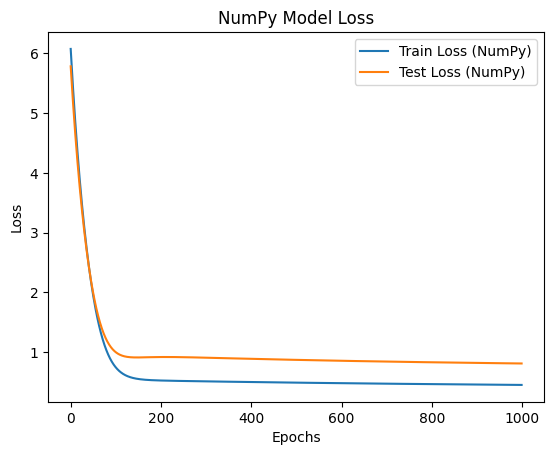

In [18]:


plt.plot(train_losses_np, label="Train Loss (NumPy)")
plt.plot(test_losses_np, label="Test Loss (NumPy)")

plt.legend()
plt.title("NumPy Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.show()

Behaviour Plot

In [19]:
def true_function(v):
    return (
        np.exp(-0.5 * v)
        + np.log(1 + np.exp(0.4 * v))
        + np.tanh(v)
        + np.sin(v)
        - 0.4
    )

Generate Input

In [20]:
values = np.linspace(0, 6, 200)
X_plot = np.stack([values, values, values, values], axis=1)

Predictions

In [21]:
preds_np = model_np.forward(X_plot).squeeze()
true_vals = true_function(values)

Plot

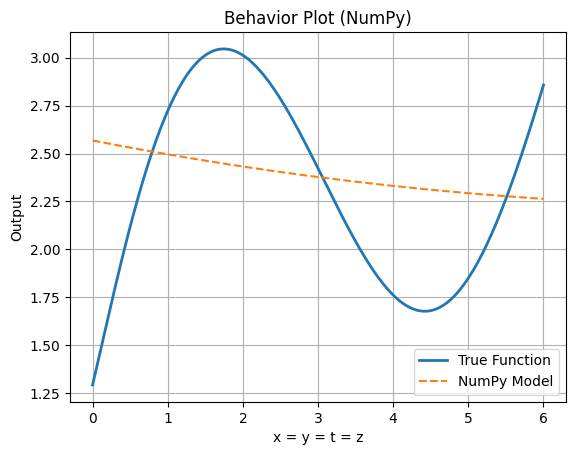

In [22]:
plt.plot(values, true_vals, label="True Function", linewidth=2)
plt.plot(values, preds_np, label="NumPy Model", linestyle="--")

plt.title("Behavior Plot (NumPy)")
plt.xlabel("x = y = t = z")
plt.ylabel("Output")

plt.legend()
plt.grid()
plt.show()